# Spatial quantification and plotting

These examples target **movement 0.17.0** and one explicitly selected session.
`data-conduit` selects, reads and aligns the experiment's DLC and event streams;
`movement` filters poses and calculates head angles and occupancy histograms.
The functions below arrange those results into reusable figures.

Run the numbered sections from top to bottom. Each analysis/plotting function
has explicit inputs, returns its results, and leaves display to the short example
call below it. Change the settings and rerun the relevant example to redraw a
figure without reloading the recording.

The time axis remains the recorded session clock in **seconds** and positions
remain **pixels**. Pose processing runs on the continuous session before display
windows are selected. The optional circular rolling mean is a display summary
implemented below; it does not replace movement's underlying angle measurements.

In [1]:
#=== 1| Import session, measurement and plotting tools ========
from pathlib import Path
import sys

# Find src/ from the checkout root or any notebook subdirectory.
for parent in (Path.cwd(), *Path.cwd().parents):
    if (parent / "movement_figures").is_dir():
        sys.path.insert(0, str(parent))
        break
    if (parent / "src" / "movement_figures").is_dir():
        sys.path.insert(0, str(parent / "src"))
        break
else:
    raise RuntimeError("Start Jupyter inside the data-conduit checkout.")

import matplotlib.pyplot as plt
import movement
import movement.kinematics as kin
import numpy as np
import pandas as pd
import xarray as xr
from IPython.display import display
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
from matplotlib.figure import Figure
from movement.plots import plot_occupancy
from movement.utils.vector import compute_signed_angle_2d

from movement_figures.data_template.loading import (
    build_config,
    load_figure_data,
    preview_session,
    read_session_video_frame,
)
from movement_figures.timeseries_template.annotations import (
    annotate_qc_timeseries,
    qc_annotations,
)

print(f"movement {movement.__version__}: {movement.__file__}")

movement 0.17.0: /home/sepi/anaconda3/envs/data-conduit-refactor/lib/python3.12/site-packages/movement/__init__.py


## Session and processing settings

In [2]:
#=== 2| Choose the session, landmarks and processing settings ========
# Session path: ROOT / mouseID / day / SESSION; SESSION is only a folder name.
ROOT = Path("/media/sepi/Elements/PathIntegrationProtocol/BonsaiOutput/Training")
SESSION = "2026-06-21T093349Z"
LEVEL_NAMES = ("mouseID", "day")
LEVEL_SELECTORS = None  # E.g. {"l0_selector": ["your-mouse"]} for repeated session names.
SOURCES = ("trials", "events", "dlc")

INDIVIDUAL = "individual_0"
TRACKING_KEYPOINT = "body"  # Occupancy uses this landmark's pixel positions.
LEFT_EAR, RIGHT_EAR = "lear", "rear"
BODY_FRONT, BODY_BACK = "body", "tailbase"  # Body axis points tailbase -> body.
CAMERA_VIEW = "top_down"  # Original image coordinates: +x right, +y down.
REFERENCE_VECTOR = (1.0, 0.0)  # Allocentric angle zero points right in the image.

CONFIDENCE_THRESHOLD = 0.9  # Low-confidence positions become NaN.
MAX_GAP_FRAMES = None  # Maximum missing samples to interpolate; None disables.
SMOOTHING_WINDOW = None  # Odd rolling-median window in samples; None disables.

TRIAL_ROWS = (0, 1, 2)  # Retained companion-notebook setting; spatial plots use all trials.
WINDOW = None  # Absolute seconds (start, end); None displays up to the first 60 s of overlap.
PLOT_MODE = "scatter"  # "scatter", "line", or "scatter+trace" for angular timeseries.
TRACE_WINDOW_SAMPLES = 15  # Centered circular rolling mean; odd sample count, not seconds.
TRACE_MAX_GAP_SECONDS = None  # None splits at gaps > 3 x the median sample interval.

config = build_config(
    ROOT,
    session=SESSION,
    level_names=LEVEL_NAMES,
    level_selectors=LEVEL_SELECTORS,
    sources=SOURCES,
)

## Load, inspect coverage, and process

In [3]:
#=== 3| Load one session and inspect the shared figure inputs ========
display(preview_session(config))
figure_data = load_figure_data(
    config,
    individual=INDIVIDUAL,
    tracking_keypoint=TRACKING_KEYPOINT,
    confidence_threshold=CONFIDENCE_THRESHOLD,
    max_gap_frames=MAX_GAP_FRAMES,
    smoothing_window=SMOOTHING_WINDOW,
)
# FigureData keeps raw poses, processed poses and the selected arrays together.
session_data = figure_data.session_data
raw_pose, pose = figure_data.raw_pose, figure_data.pose
position, point = figure_data.position, figure_data.point
trials, events = figure_data.trials, figure_data.events

display(session_data.loaded.stream_coverage)
display(trials)
for note in qc_annotations(trials, events).notes:
    print(note)
print("Keypoints:", position.keypoint.values.tolist())
print("Valid tracked-point frames:", int(point.notnull().all("space").sum()), "/", point.sizes["time"])

,path,mouseID,day,label
session,,,,
2026-06-21T093349Z,/media/sepi/Elements/PathIntegrationProtocol/B...,MR_M01569515,Day21,2026-06-21T093349Z



                  If any files/paths are missing or invalid for the monosource_data_arrays you specified, 
                  you may not see warnings about them. Set verbose=True to enable warnings.
                  

                  If any files/paths are missing or invalid for the monosource_data_arrays you specified, 
                  you may not see warnings about them. Set verbose=True to enable warnings.
                  


,dlc:position,dlc:confidence,trials,events
session,,,,
2026-06-21T093349Z,True,True,True,True


,trial_index,start_time,end_time,tz_triggered_time,tz_available_time,ChosenPort,CorrectPort,outcome,LED,angle_offset,target_zone_size,TTT,TTP,outbound_start_time,outbound_end_time,inbound_start_time,inbound_end_time,session,mouseID,day
0,1,5633.836992,5667.029120,5663.198976,5640.910976,0,0,Success,ON,0.0,150.0,29.361984,3.830144,5633.836992,5663.198976,5663.198976,5667.029120,2026-06-21T093349Z,MR_M01569515,Day21
1,2,5667.029120,5681.075968,5678.849984,5675.540992,0,0,Success,ON,0.0,150.0,11.820864,2.225984,5667.029120,5678.849984,5678.849984,5681.075968,2026-06-21T093349Z,MR_M01569515,Day21
2,3,5681.075968,5695.245088,5693.349984,5690.241984,0,0,Success,ON,0.0,150.0,12.274016,1.895104,5681.075968,5693.349984,5693.349984,5695.245088,2026-06-21T093349Z,MR_M01569515,Day21
3,4,5695.245088,5709.933824,5707.698976,5697.756000,0,0,Success,OFF,0.0,400.0,12.453888,2.234848,5695.245088,5707.698976,5707.698976,5709.933824,2026-06-21T093349Z,MR_M01569515,Day21
4,5,5709.933824,5721.442080,5719.708992,5719.392000,0,0,Success,ON,0.0,150.0,9.775168,1.733088,5709.933824,5719.708992,5719.708992,5721.442080,2026-06-21T093349Z,MR_M01569515,Day21
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
101,102,7311.543744,7328.291776,7325.601984,7319.292384,0,0,Success,OFF,0.0,150.0,14.058240,2.689792,7311.543744,7325.601984,7325.601984,7328.291776,2026-06-21T093349Z,MR_M01569515,Day21
102,103,7328.291776,7349.316480,7344.304000,7335.678976,-1,0,Miss,OFF,NaN,150.0,16.012224,5.012480,7328.291776,7344.304000,7344.304000,7349.316480,2026-06-21T093349Z,MR_M01569515,Day21
103,104,7349.316480,7370.981504,7365.952992,7356.648000,-1,0,Miss,OFF,NaN,150.0,16.636512,5.028512,7349.316480,7365.952992,7365.952992,7370.981504,2026-06-21T093349Z,MR_M01569515,Day21
104,105,7370.981504,7417.264352,7414.952992,7379.677984,0,0,Success,OFF,0.0,150.0,43.971488,2.311360,7370.981504,7414.952992,7414.952992,7417.264352,2026-06-21T093349Z,MR_M01569515,Day21


Keypoints: ['nose', 'lear', 'rear', 'body', 'tailbase']
Valid tracked-point frames: 35654 / 36354


## Allocentric heading and head direction relative to the body

**Allocentric heading** is the head's angle from `REFERENCE_VECTOR` in the
original image coordinates. With the default `(1, 0)`, zero points right.
**Head relative to body** compares the ear-derived head vector with the body axis
(`BODY_BACK` → `BODY_FRONT`). These are different measurements from a target's
bearing relative to the head. Ear-derived direction assumes symmetric left/right
labels. Movement performs both angle calculations, returning radians within ±π.
With image +y down, positive angles are clockwise.

`PLOT_MODE` controls the angular timeseries: `"scatter"` shows measured angles;
`"line"` connects them; `"scatter+trace"` adds a labelled **circular rolling mean**
to the scatter. The mean averages sine and cosine before converting back to an
angle, so values near −π and +π are not averaged toward zero. Its centered window
is `TRACE_WINDOW_SAMPLES` samples (an odd positive integer), with shorter windows
at segment edges; it is a descriptive trace, not a fitted model.

Missing samples and recording gaps split the mean into independent segments.
`TRACE_MAX_GAP_SECONDS = None` detects gaps greater than three times the median
recorded interval; set seconds explicitly for irregular sampling. Every drawn line
also breaks at jumps greater than π, so it never connects across the wrap boundary.
Heatmaps below retain occupancy rendering: a scatter/line toggle would change what
a spatial bin count represents.

In [4]:
#=== 4| Define reusable head-angle measurements and circular traces ========
def compute_head_angles(
    position: xr.DataArray,
    *,
    left_ear: str,
    right_ear: str,
    body_front: str,
    body_back: str,
    reference_vector: tuple[float, float] = (1.0, 0.0),
    camera_view: str = "top_down",
) -> xr.Dataset:
    """Calculate allocentric and body-relative head angles with movement.

    Parameters
    ----------
    position : xarray.DataArray
        Pixel coordinates with dimensions (time, space, keypoint), for one animal.
        The time coordinate contains absolute session-clock seconds.
    left_ear, right_ear, body_front, body_back : str
        Keypoint names defining the head and body forward vectors.
    reference_vector : tuple of float
        Fixed arena/image direction defining zero allocentric angle.
    camera_view : str
        Camera convention accepted by movement (this notebook uses top_down).

    Returns
    -------
    xarray.Dataset
        allocentric_heading and head_relative_to_body, each with dimension time
        in radians within [-pi, pi]. Missing positions remain missing angles.
    """

    #=== 1| Validate the selected animal and landmark names ========
    if set(position.dims) != {"time", "space", "keypoint"}:
        raise ValueError("position must have dimensions time, space and keypoint.")
    requested = {left_ear, right_ear, body_front, body_back}
    missing = requested - set(position.keypoint.values.tolist())
    if missing:
        raise ValueError(f"Unknown head/body keypoints: {sorted(missing)}")

    #=== 2| Calculate the head angle from a fixed image direction ========
    allocentric_heading = kin.compute_forward_vector_angle(
        position,
        left_keypoint=left_ear,
        right_keypoint=right_ear,
        reference_vector=reference_vector,
        camera_view=camera_view,
    )

    #=== 3| Compare head direction with the body forward vector ========
    head_forward = kin.compute_head_direction_vector(
        position,
        left_keypoint=left_ear,
        right_keypoint=right_ear,
        camera_view=camera_view,
    )
    body_forward = (
        position.sel(keypoint=body_front, drop=True)
        - position.sel(keypoint=body_back, drop=True)
    )
    head_relative_to_body = compute_signed_angle_2d(body_forward, head_forward)

    #=== 4| Return both measurements with their original clock and units ========
    result = xr.Dataset({
        "allocentric_heading": allocentric_heading,
        "head_relative_to_body": head_relative_to_body,
    })
    for name in result.data_vars:
        result[name].attrs["units"] = "rad"
    return result


def angle_segments(
    angle: xr.DataArray,
    *,
    max_gap_seconds: float | None = None,
    split_wrap: bool = False,
) -> list[np.ndarray]:
    """Return valid sample-index runs, splitting missing values and clock gaps.

    angle must have only a time dimension, radians, and strictly increasing finite
    timestamps in seconds. None uses a gap threshold of three times the median
    interval. split_wrap additionally splits jumps greater than pi for drawing;
    keep it False when computing a circular mean across the wrap boundary.
    """

    #=== 1| Validate the angle array and recording-gap threshold ========
    if angle.dims != ("time",):
        raise ValueError("angle must have exactly one dimension: time.")
    times = np.asarray(angle.time.values, dtype=float)
    values = np.asarray(angle.values, dtype=float)
    if not np.isfinite(times).all() or np.any(np.diff(times) <= 0):
        raise ValueError("Angle timestamps must be finite, increasing seconds.")
    if max_gap_seconds is None:
        gap_limit = 3 * float(np.median(np.diff(times))) if len(times) > 1 else np.inf
    elif not np.isfinite(max_gap_seconds) or max_gap_seconds <= 0:
        raise ValueError("max_gap_seconds must be finite and positive, or None.")
    else:
        gap_limit = float(max_gap_seconds)

    #=== 2| Find breaks caused by missing samples, gaps or circular wrapping ========
    valid_indices = np.flatnonzero(np.isfinite(values))
    if not len(valid_indices):
        return []
    # Nonconsecutive indices reveal missing samples, even if clock gaps are small.
    breaks = (np.diff(valid_indices) > 1) | (np.diff(times[valid_indices]) > gap_limit)
    if split_wrap:
        breaks |= np.abs(np.diff(values[valid_indices])) > np.pi

    #=== 3| Return separate runs of valid sample indices ========
    return list(np.split(valid_indices, np.flatnonzero(breaks) + 1))


def circular_rolling_trace(
    angle: xr.DataArray,
    *,
    window_samples: int = 15,
    max_gap_seconds: float | None = None,
) -> xr.DataArray:
    """Return a centered circular rolling mean in radians on the original clock.

    window_samples is an odd positive sample count, not a duration. Each finite,
    contiguous recording segment is processed separately; shorter edge windows
    use the available samples. Missing samples remain NaN. Means with essentially
    zero resultant length (e.g. opposing directions) are undefined and become NaN.
    angle is a time-only DataArray whose coordinate contains absolute seconds.
    max_gap_seconds sets the recording-gap threshold; None uses three times the
    median sample interval. The implementation averages sin(angle)/cos(angle),
    not wrapped radians.
    """

    #=== 1| Validate the sample-based circular averaging window ========
    if (
        isinstance(window_samples, (bool, np.bool_))
        or not isinstance(window_samples, (int, np.integer))
        or window_samples < 1
        or window_samples % 2 == 0
    ):
        raise ValueError("window_samples must be an odd positive integer.")

    #=== 2| Average sine and cosine within each recording segment ========
    trace = np.full(angle.shape, np.nan, dtype=float)
    for indices in angle_segments(angle, max_gap_seconds=max_gap_seconds):
        values = np.asarray(angle.values[indices], dtype=float)
        mean_sine = pd.Series(np.sin(values)).rolling(
            window_samples, center=True, min_periods=1
        ).mean().to_numpy()
        mean_cosine = pd.Series(np.cos(values)).rolling(
            window_samples, center=True, min_periods=1
        ).mean().to_numpy()
        result = np.arctan2(mean_sine, mean_cosine)
        result[np.hypot(mean_sine, mean_cosine) <= 1e-12] = np.nan
        trace[indices] = result

    #=== 3| Return the trace on the original clock with descriptive attributes ========
    result = angle.copy(data=trace)
    result.attrs = {**angle.attrs, "units": "rad", "summary": "circular rolling mean",
                    "window_samples": int(window_samples)}
    return result


#=== 5| Define the angular timeseries figure ========
def plot_head_angles(
    angles: xr.Dataset,
    trials: pd.DataFrame,
    events: pd.DataFrame | None = None,
    *,
    window: tuple[float, float] | None = None,
    mode: str = "scatter",
    trace_window_samples: int = 15,
    max_gap_seconds: float | None = None,
) -> tuple[Figure, np.ndarray, xr.Dataset | None]:
    """Plot two head-angle measurements with session-clock trial annotations.

    angles is the Dataset returned by compute_head_angles; trials/events must
    belong to the same session and use the same absolute seconds. window=None
    displays up to 60 seconds from the first trial/pose overlap. mode selects raw
    scatter, a raw line, or raw scatter plus a circular rolling mean. The trace is
    computed over the full recording before slicing the display window.
    trace_window_samples is the circular mean's odd positive sample count.
    max_gap_seconds controls gap splitting for both raw lines and traces; None
    uses three times the median recorded interval, calculated on the full clock.

    Returns (figure, axes, traces). traces is a full-clock Dataset for
    scatter+trace, otherwise None. Every drawn line breaks at NaNs, clock gaps,
    and jumps across +/-pi. One shared legend sits below the data panels.
    The function creates a figure but never calls show.
    """

    #=== 1| Validate measurements, plot mode and display window ========
    if mode not in {"scatter", "line", "scatter+trace"}:
        raise ValueError("mode must be 'scatter', 'line', or 'scatter+trace'.")
    names = ("allocentric_heading", "head_relative_to_body")
    if not all(name in angles for name in names) or not angles.sizes.get("time", 0):
        raise ValueError("angles must contain both head-angle variables and time samples.")
    if trials.empty:
        raise ValueError("At least one trial is needed for annotated head-angle plots.")
    # Validate recording clocks/gap settings even when only scatter is requested.
    for name in names:
        angle_segments(angles[name], max_gap_seconds=max_gap_seconds)
    if window is None:
        start = max(float(angles.time.min()), float(trials.start_time.min()))
        window = (start, min(start + 60, float(angles.time.max())))
    if len(window) != 2 or not np.isfinite(window).all() or window[0] >= window[1]:
        raise ValueError("window must contain two finite increasing session times.")
    if not bool(((angles.time >= window[0]) & (angles.time <= window[1])).any()):
        raise ValueError("window contains no recorded angle samples.")

    #=== 2| Calculate the optional trace before slicing the display window ========
    traces = None
    if mode == "scatter+trace":
        traces = xr.Dataset({
            name: circular_rolling_trace(
                angles[name], window_samples=trace_window_samples,
                max_gap_seconds=max_gap_seconds,
            )
            for name in names
        })

    #=== 3| Draw both angle panels with safe line segments and trial labels ========
    fig, axes = plt.subplots(2, 1, figsize=(13, 6), sharex=True, layout="constrained")
    labels = ("Allocentric head heading", "Head relative to body")
    legend_handles = {}
    for index, (ax, name, label) in enumerate(zip(axes, names, labels)):
        visible = angles[name].sel(time=slice(*window))
        if mode in {"scatter", "scatter+trace"}:
            ax.plot(visible.time, visible, linestyle="none", marker=".", ms=2.5,
                    color="#5b4b9a", alpha=0.55 if traces is not None else 1.0,
                    label="Measured angle")
        line = angles[name] if mode == "line" else traces[name] if traces is not None else None
        if line is not None:
            line_label = (
                "Measured angle" if mode == "line" else
                f"Circular rolling mean ({trace_window_samples} samples)"
            )
            # Detect gaps on the full clock, before slicing the display window.
            label_pending = True
            for indices in angle_segments(
                line, max_gap_seconds=max_gap_seconds, split_wrap=True
            ):
                segment = line.isel(time=indices).sel(time=slice(*window))
                if not segment.sizes["time"]:
                    continue
                ax.plot(
                    segment.time,
                    segment,
                    color="#5b4b9a" if mode == "line" else "#bd482f",
                    linewidth=1.0 if mode == "line" else 1.7,
                    label=line_label if label_pending else "_nolegend_",
                )
                label_pending = False
        ax.set_ylim(-np.pi, np.pi)
        ax.set_yticks([-np.pi, 0, np.pi], ["−π", "0", "π"])
        ax.set_ylabel(f"{label} (rad)")
        annotation_result = annotate_qc_timeseries(
            ax, trials, events, window=window, legend=False
        )
        # Collect handles from both panels so missing data cannot omit a label.
        for handle in annotation_result.legend_handles:
            legend_handles.setdefault(handle.get_label(), handle)

    #=== 4| Place one shared legend below the panels ========
    axes[-1].set_xlabel("Session time (s)")
    fig.legend(
        handles=list(legend_handles.values()),
        loc="outside lower center",
        ncol=4,
        fontsize=8,
    )

    #=== 5| Return the figure, axes and optional circular traces ========
    return fig, axes, traces

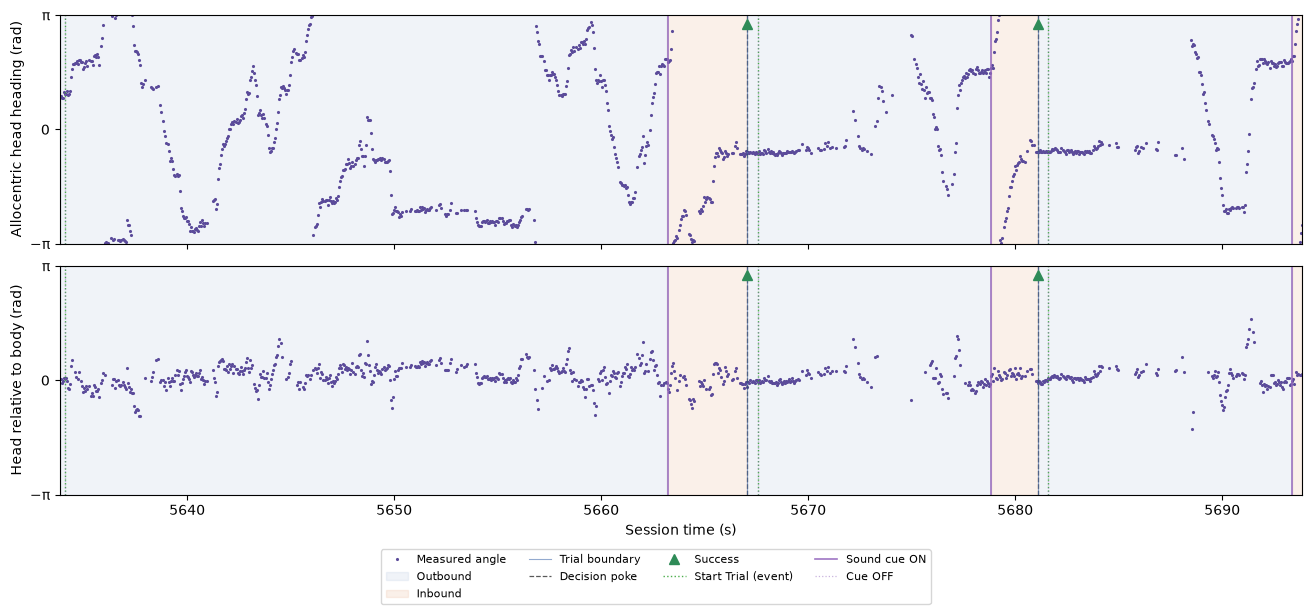

In [5]:
#=== 6| Calculate and display this session's head angles ========
head_angles = compute_head_angles(
    position,
    left_ear=LEFT_EAR,
    right_ear=RIGHT_EAR,
    body_front=BODY_FRONT,
    body_back=BODY_BACK,
    reference_vector=REFERENCE_VECTOR,
    camera_view=CAMERA_VIEW,
)
angle_figure, angle_axes, angle_traces = plot_head_angles(
    head_angles, trials, events,
    window=WINDOW,
    mode=PLOT_MODE,
    trace_window_samples=TRACE_WINDOW_SAMPLES,
    max_gap_seconds=TRACE_MAX_GAP_SECONDS,
)
plt.show()

## Occupancy: whole session, outbound, and inbound

`movement.plots.plot_occupancy` reports **valid position samples per spatial bin**.
Counts are not dwell-time seconds, particularly if frame intervals are irregular.
Phase panels use only trials with known valid target-trigger boundaries. The
whole-session panel also includes inter-trial periods and trials without those
boundaries. Phases use half-open intervals, so a target-trigger sample belongs
to inbound and the end sample cannot be counted twice across adjacent trials.

All panels share spatial bin edges and the same colour limits; differing phase
durations therefore affect the raw counts. No probability or time normalisation
is applied. Missing tracked positions are excluded by movement.

The background is the **first frame of the selected session's video**, in its
original pixel coordinates. Use `UndistortedVideoData` for DLC tracked on the
undistorted recordings (as in this session); use `VideoData` only for raw-video
coordinates. Empty bins are transparent and `OCCUPANCY_ALPHA` controls the overlay.

Set `USE_OCCUPANCY_VMAX = True` and adjust `OCCUPANCY_VMAX` (samples per bin) to
control the shared colour scale. Set the switch to `False` for the observed
maximum. Counts above a chosen maximum use the top colour, indicated by the
colourbar's pointed end; the underlying counts remain intact. Raising the maximum
reduces colour saturation; lowering it makes low-occupancy paths easier to see.
Edit these plot controls and rerun the heatmap cell without reloading the data.


In [6]:
#=== 7| Control occupancy bins, colour limits and video background ========
OCCUPANCY_BINS = 30  # Bins along each image axis: 20 x 20 spatial bins.
USE_OCCUPANCY_VMAX = True  # False uses the largest observed count across all panels.
OCCUPANCY_VMAX = 100.0  # Display ceiling in samples/bin; raw counts remain unchanged.
OCCUPANCY_ALPHA = 0.70  # Overlay opacity; empty bins always reveal the video.
OCCUPANCY_VIDEO_SUBDIR = "UndistortedVideoData"  # Must match the video tracked by DLC.
ARENA_RANGE = None  # Optional ((xmin, xmax), (ymin, ymax)) for binning and display crop.

In [7]:
#=== 8| Define trial-phase selection for occupancy ========
def compute_phase_masks(
    time: xr.DataArray,
    trials: pd.DataFrame,
) -> tuple[dict[str, np.ndarray], int]:
    """Return outbound/inbound Boolean masks and the number of valid phase trials.

    time is the tracked point's one-dimensional session clock in seconds. trials
    needs start_time, tz_triggered_time and end_time on that same clock. Only
    finite, strictly increasing start < target < end boundaries contribute.
    Half-open intervals [start, target) and [target, end) assign the target sample
    to inbound and exclude the trial-end sample, avoiding shared-boundary counts.
    Each returned mask has one Boolean per input time sample.
    """

    #=== 1| Validate the trial boundaries and pose clock ========
    if time.dims != ("time",):
        raise ValueError("time must be a one-dimensional time coordinate.")
    required = {"start_time", "tz_triggered_time", "end_time"}
    if not required.issubset(trials.columns):
        raise ValueError(f"Trial table needs phase columns: {sorted(required)}")
    times = np.asarray(time.values, dtype=float)
    if not np.isfinite(times).all() or np.any(np.diff(times) <= 0):
        raise ValueError("Pose timestamps must be finite, increasing seconds.")

    #=== 2| Assign recorded samples to valid half-open phase intervals ========
    masks = {
        "Outbound": np.zeros(len(times), dtype=bool),
        "Inbound": np.zeros(len(times), dtype=bool),
    }
    phase_trial_count = 0
    for trial in trials.itertuples():
        start, split, end = map(float, (trial.start_time, trial.tz_triggered_time, trial.end_time))
        if np.isfinite([start, split, end]).all() and start < split < end:
            masks["Outbound"] |= (times >= start) & (times < split)
            masks["Inbound"] |= (times >= split) & (times < end)
            phase_trial_count += 1

    #=== 3| Return phase masks and the number of contributing trials ========
    return masks, phase_trial_count


#=== 9| Define the video-backed occupancy figure ========
def plot_spatial_occupancy(
    point: xr.DataArray,
    phase_masks: dict[str, np.ndarray],
    background_frame: np.ndarray,
    *,
    bins: int = 20,
    arena_range: tuple[tuple[float, float], tuple[float, float]] | None = None,
    use_vmax: bool = True,
    vmax: float = 100.0,
    alpha: float = 0.70,
    title: str | None = None,
) -> tuple[Figure, np.ndarray, dict[str, dict[str, np.ndarray]]]:
    """Overlay whole-session and phase occupancy on a matching video frame.

    Parameters
    ----------
    point : xarray.DataArray
        One tracked keypoint, dimensions (time, space), with x/y coordinates in
        original video pixels. NaN/inf coordinate pairs are excluded.
    phase_masks : dict
        Outbound and Inbound Boolean arrays from compute_phase_masks.
    background_frame : numpy.ndarray
        First RGB/RGBA frame from the same raw/undistorted video used for tracking.
    bins : int
        Positive bin count per spatial axis. All panels share the same edges.
    arena_range : tuple or None
        Optional ((xmin, xmax), (ymin, ymax)) for binning and display. None bins
        over valid tracked positions and displays the full video frame. An
        automatically inferred constant axis expands by half a pixel each way.
    use_vmax, vmax, alpha : bool, float, float
        Enable a manual colour ceiling (samples/bin) and set overlay opacity.
        Automatic scaling uses the largest count across the three panels.
    title : str or None
        Optional figure title, supplied by the caller.

    Returns
    -------
    figure, axes, occupancy
        occupancy maps nonempty panel labels to movement's raw histogram dicts:
        h[x_bin, y_bin], xedges and yedges. Counts are samples, not dwell seconds
        or probabilities. The colour cap and transparent zero bins affect only
        drawing. The function creates a figure but never calls show.
    """

    #=== 1| Validate tracked coordinates, phase masks and display settings ========
    if point.dims != ("time", "space") or list(point.space.values) != ["x", "y"]:
        raise ValueError("point must have dimensions (time, space) with space=['x', 'y'].")
    if isinstance(bins, (bool, np.bool_)) or not isinstance(bins, (int, np.integer)) or bins < 1:
        raise ValueError("bins must be a positive integer.")
    if use_vmax and (not np.isfinite(vmax) or vmax <= 0):
        raise ValueError("vmax must be finite and positive when use_vmax=True.")
    if not np.isfinite(alpha) or not 0 <= alpha <= 1:
        raise ValueError("alpha must be between 0 and 1.")
    frame = np.asarray(background_frame)
    if frame.ndim != 3 or frame.shape[2] not in (3, 4) or min(frame.shape[:2]) == 0:
        raise ValueError("background_frame must be a nonempty RGB or RGBA image.")
    for label in ("Outbound", "Inbound"):
        mask = np.asarray(phase_masks.get(label))
        if mask.shape != (point.sizes["time"],) or mask.dtype != np.bool_:
            raise ValueError(f"{label} must have one Boolean per point timestamp.")

    #=== 2| Determine common histogram limits from valid tracked positions ========
    finite_point = point.where(np.isfinite(point).all("space"), drop=True)
    if not finite_point.sizes["time"]:
        raise ValueError("No valid positions for occupancy.")
    occupancy_range = arena_range
    if occupancy_range is None:
        inferred_ranges = []
        for axis in ("x", "y"):
            axis_positions = finite_point.sel(space=axis)
            low, high = float(axis_positions.min()), float(axis_positions.max())
            if low == high:
                # A stationary coordinate still needs finite-width histogram bins.
                low, high = low - 0.5, high + 0.5
            inferred_ranges.append((low, high))
        occupancy_range = tuple(inferred_ranges)
    limits = np.asarray(occupancy_range, dtype=float)
    if limits.shape != (2, 2) or not np.isfinite(limits).all() or np.any(limits[:, 0] >= limits[:, 1]):
        raise ValueError("arena_range needs a finite, nonzero range on both axes.")

    #=== 3| Align the video frame and phase selections in image coordinates ========
    # Half-pixel edges keep integer DLC coordinates at the image's pixel centres.
    frame_height, frame_width = frame.shape[:2]
    frame_extent = (-0.5, frame_width - 0.5, frame_height - 0.5, -0.5)
    view_range = arena_range if arena_range is not None else (
        (frame_extent[0], frame_extent[1]), (frame_extent[3], frame_extent[2])
    )
    phase_points = {
        "Whole session": point,
        "Outbound": point.isel(time=phase_masks["Outbound"]),
        "Inbound": point.isel(time=phase_masks["Inbound"]),
    }

    #=== 4| Draw raw occupancy histograms over the matching video frame ========
    fig, axes = plt.subplots(1, 3, figsize=(16, 6), dpi=140, sharex=True, sharey=True,
                             layout="constrained")
    # Leave vertical space between panel titles and one- or two-line headings.
    fig.get_layout_engine().set(h_pad=0.15)  # Padding is in inches, not pixels.
    cmap = plt.get_cmap("magma").with_extremes(bad=(0, 0, 0, 0))
    occupancy, heatmaps = {}, []
    observed_max = 0.0
    for ax, (label, data) in zip(axes, phase_points.items()):
        ax.imshow(frame, origin="upper", extent=frame_extent, zorder=0)
        data = data.where(np.isfinite(data).all("space"), drop=True)
        if not data.sizes["time"]:
            ax.text(0.5, 0.5, "No valid samples", ha="center", va="center", color="white",
                    fontsize=12, bbox={"facecolor": "black", "alpha": 0.65}, transform=ax.transAxes)
        else:
            # movement owns the histogram computation and returns its unmodified counts.
            _, _, histogram = plot_occupancy(
                data, ax=ax, bins=bins, range=occupancy_range,
                cmap=cmap, alpha=alpha, zorder=1,
            )
            occupancy[label] = histogram
            observed_max = max(observed_max, float(histogram["h"].max()))
            mesh = ax.collections[-1]
            mesh.colorbar.remove()  # Replace per-panel colourbars with one shared scale.
            # Histogram axes are [x_bin, y_bin]; mesh drawing uses [y_bin, x_bin].
            mesh.set_array(np.ma.masked_equal(histogram["h"].T, 0))
            heatmaps.append(mesh)
        ax.set_title(label, fontsize=15, fontweight="semibold", pad=10)
        ax.set_xlim(*view_range[0])
        ax.set_ylim(view_range[1][1], view_range[1][0])  # Image y increases downward.
        ax.set_aspect("equal")
        ax.set_xlabel("x (px)", fontsize=12)
        ax.set_ylabel("y (px)" if ax is axes[0] else "", fontsize=12)
        ax.tick_params(labelsize=11)

    #=== 5| Apply shared colour limits and draw the occupancy key ========
    colour_limit = float(vmax) if use_vmax else max(1.0, observed_max)
    norm = Normalize(vmin=0, vmax=colour_limit)
    for mesh in heatmaps:
        mesh.set_norm(norm)
    # An independent mappable keeps the key opaque while the overlay is translucent.
    colourbar = fig.colorbar(
        ScalarMappable(norm=norm, cmap=cmap), ax=list(axes), orientation="horizontal",
        fraction=0.06, pad=0.09, shrink=0.65, aspect=45,
        extend="max" if observed_max > colour_limit else "neither",
    )
    colourbar.set_label("Valid position samples / bin", fontsize=12)
    colourbar.ax.tick_params(labelsize=11)
    if title is not None:
        fig.suptitle(title, fontsize=17, fontweight="semibold")

    #=== 6| Return the figure, axes and unmodified sample counts ========
    return fig, axes, occupancy

findfont: Failed to find font weight semibold, now using 700.
findfont: Failed to find font weight semibold, now using 700.


Background: Training_MR_M01569515_Day21_093349Z.avi, first frame
Known phase boundaries: 106/106 trials


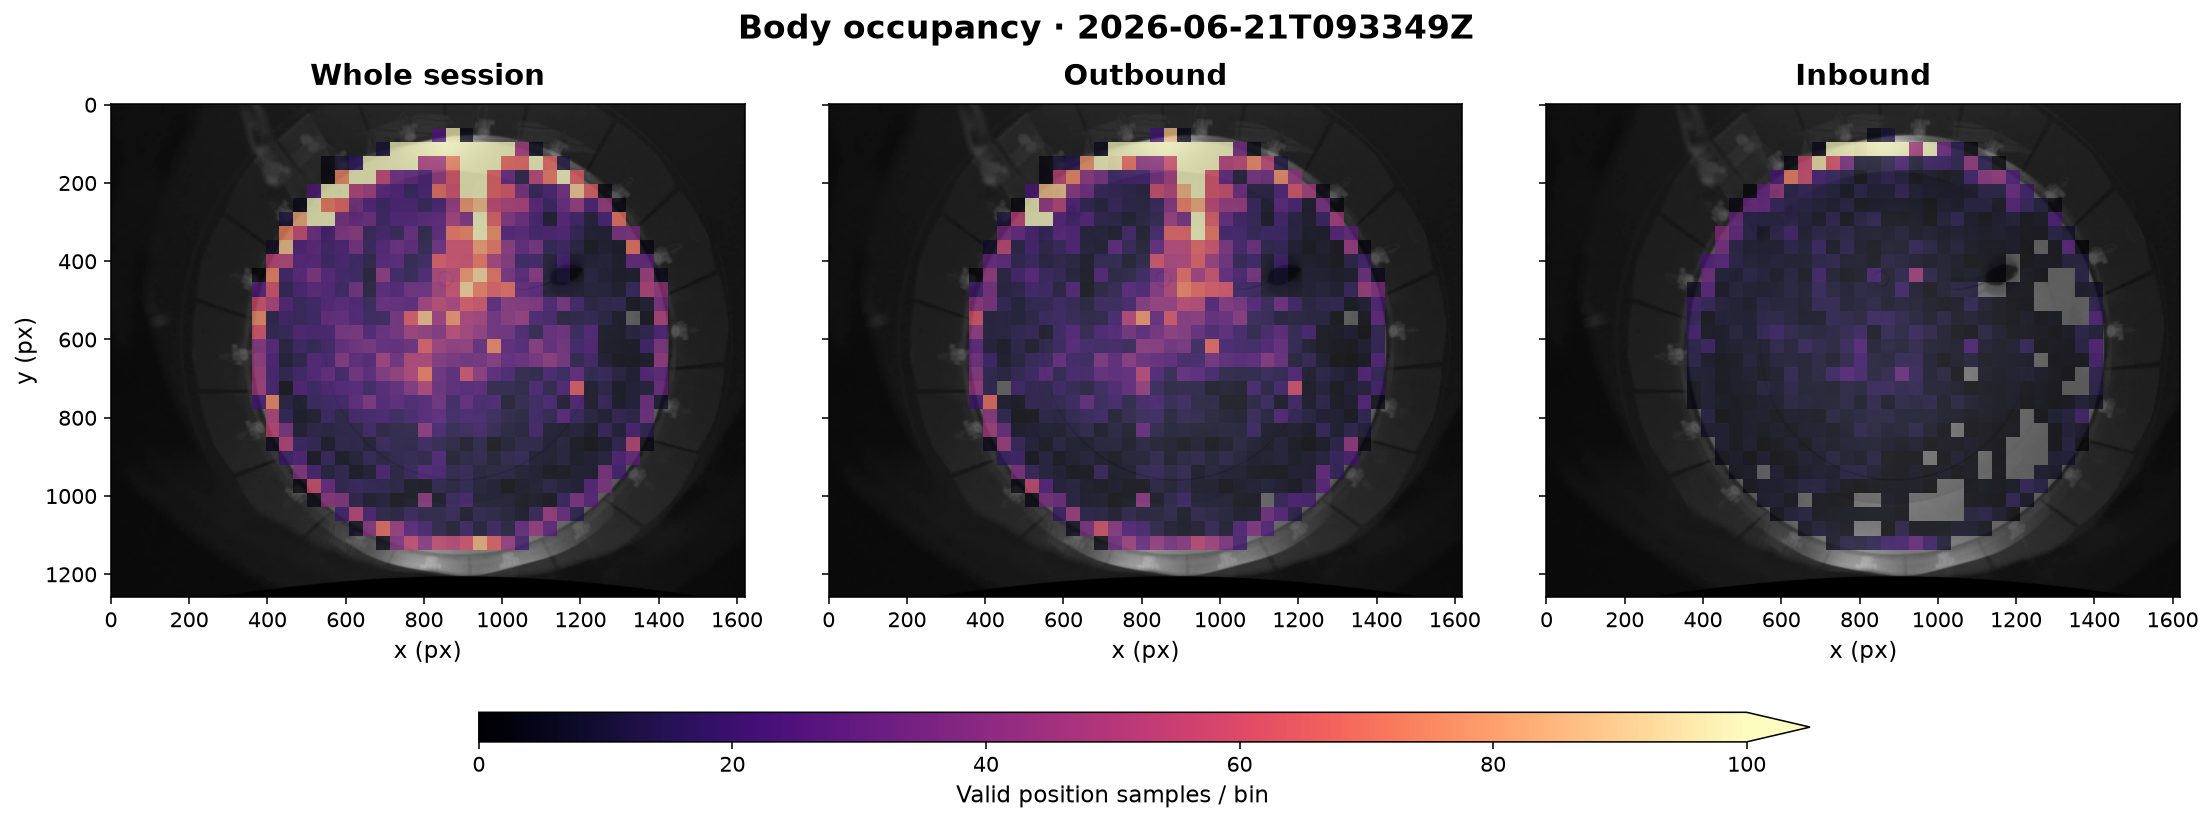

In [8]:
#=== 10| Read the matching first video frame and display occupancy ========
session_path = Path(session_data.loaded.session_manifest.iloc[0]["path"])
background_frame, video_path = read_session_video_frame(
    session_path, video_subdir=OCCUPANCY_VIDEO_SUBDIR
)
phase_masks, phase_trial_count = compute_phase_masks(point.time, trials)
print(f"Background: {video_path.name}, first frame")
print(f"Known phase boundaries: {phase_trial_count}/{len(trials)} trials")
occupancy_figure, occupancy_axes, occupancy = plot_spatial_occupancy(
    point, phase_masks, background_frame,
    bins=OCCUPANCY_BINS,
    arena_range=ARENA_RANGE,
    use_vmax=USE_OCCUPANCY_VMAX,
    vmax=OCCUPANCY_VMAX,
    alpha=OCCUPANCY_ALPHA,
    title=f"{TRACKING_KEYPOINT.title()} occupancy · {SESSION}",
)
plt.show()

API references: [head-direction example](https://movement.neuroinformatics.dev/latest/examples/compute_head_direction.html),
[forward-vector angle](https://movement.neuroinformatics.dev/latest/api/movement.kinematics.compute_forward_vector_angle.html),
[signed angle](https://movement.neuroinformatics.dev/latest/api/movement.utils.vector.compute_signed_angle_2d.html),
[occupancy](https://movement.neuroinformatics.dev/latest/api/movement.plots.plot_occupancy.html).